In [32]:
from project.utilities.simulation import run_trials, run_task, run_experiments, get_CI
from project.utilities.statistics import bootstrap_ci, bootstrap_difference_ci
from project.utilities.io import load_results, save_plot, use_latex_fonts, figure_size

import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from dataclasses import asdict, replace
from scipy.stats import bootstrap

from pathlib import Path
import pandas as pd


# For displaying
from IPython.display import display

# Change font of plots
use_latex_fonts()

# Lowest Passing Coherence - Accuracy

Pathway-bias comparison for the suite3 and suite4 learning data. Carried out in an analogous to `cortical processing effect.ipynb`. The goal is to find the lowest passing coherence resulting in $95\%$ percent accuracy

### Loading Data

In [33]:
suite3_summary_by_bias = {
    -0.10: load_results("suite3_m10_summary.csv", '../../data/learning' ),
    0.10: load_results("suite3_10_summary.csv", '../../data/learning' ),
    0.20: load_results("suite3_20_summary.csv", '../../data/learning' ),
}

suite4_summary_by_bias = {
    -0.10: load_results("suite4_m10_summary.csv", '../../data/learning' ),
    0.10: load_results("suite4_10_summary.csv", '../../data/learning' ),
    0.20: load_results("suite4_20_summary.csv", '../../data/learning' ),
}

Loaded: ..\..\data\learning\suite3_m10_summary.csv
Loaded: ..\..\data\learning\suite3_10_summary.csv
Loaded: ..\..\data\learning\suite3_20_summary.csv
Loaded: ..\..\data\learning\suite4_m10_summary.csv
Loaded: ..\..\data\learning\suite4_10_summary.csv
Loaded: ..\..\data\learning\suite4_20_summary.csv


### Find Lowest Passing Coherence

In [34]:
def get_lowest_passing_thresholds(
    df,
    level_col,
    pathway_bias,
    suite_name,
    coherence_col="coherence",
    accurate_col="Accuracy (%)",
    accuracy_cutoff=95,
):
    data = df.copy()
    data["coherence_pct"] = data[coherence_col] * 100

    accuracy_table = (
        data.groupby([level_col, "coherence_pct"])[accurate_col]
        .mean()
        .reset_index(name="accuracy_pct")
        .sort_values([level_col, "coherence_pct"])
    )


    rows = []
    for level_value, group in accuracy_table.groupby(level_col):
        group = group.sort_values("coherence_pct")
        passing = group[group["accuracy_pct"] >= accuracy_cutoff]

        rows.append(
            {
                "suite": suite_name,
                "level_parameter": level_col,
                "level_value": level_value,
                "pathway_bias": pathway_bias,
                "lowest_passing_coherence_pct": (
                    np.nan if passing.empty else passing.iloc[0]["coherence_pct"]
                ),
            }
        )

    return pd.DataFrame(rows), accuracy_table


def compare_lowest_passing_coherence(
    suite3_summary_by_bias,
    suite4_summary_by_bias,
    suite3_level_col="noise_std",
    suite4_level_col="strength",
    accuracy_cutoff=95,
):
    threshold_frames = []

    for pathway_bias, df in suite3_summary_by_bias.items():
        thresholds, _ = get_lowest_passing_thresholds(
            df=df,
            level_col=suite3_level_col,
            pathway_bias=pathway_bias,
            suite_name="Suite 3",
            accuracy_cutoff=accuracy_cutoff,
        )
        threshold_frames.append(thresholds)

    for pathway_bias, df in suite4_summary_by_bias.items():
        thresholds, _ = get_lowest_passing_thresholds(
            df=df,
            level_col=suite4_level_col,
            pathway_bias=pathway_bias,
            suite_name="Suite 4",
            accuracy_cutoff=accuracy_cutoff,
        )
        threshold_frames.append(thresholds)

    thresholds_long = pd.concat(threshold_frames, ignore_index=True)

    comparison = (
        thresholds_long.pivot_table(
            index=["suite", "level_parameter", "level_value"],
            columns="pathway_bias",
            values="lowest_passing_coherence_pct",
            aggfunc="first",
        )
        .reset_index()
        .rename_axis(columns=None)
    )

    bias_labels = {
        -0.10: r"$b = -0.10$",
        0.10: r"$b = 0.10$",
        0.20: r"$b = 0.20$",
    }
    comparison = comparison.rename(columns=bias_labels)

    suite_order = {"Suite 4": 0, "Suite 3": 1}
    comparison["suite_order"] = comparison["suite"].map(suite_order)
    comparison = (
        comparison.sort_values(["suite_order", "level_value"])
        .drop(columns="suite_order")
        .reset_index(drop=True)
    )

    return comparison, thresholds_long

In [35]:
comparison, thresholds_long = compare_lowest_passing_coherence(
    suite3_summary_by_bias=suite3_summary_by_bias,
    suite4_summary_by_bias=suite4_summary_by_bias,
    accuracy_cutoff=95,
)

comparison

,suite,level_parameter,level_value,$b = -0.10$,$b = 0.10$,$b = 0.20$
0,Suite 4,strength,0.400,100.0,8.0,5.0
1,Suite 4,strength,0.600,30.0,5.0,3.0
2,Suite 4,strength,0.800,10.0,3.0,3.0
3,Suite 3,noise_std,0.125,8.0,3.0,3.0
4,Suite 3,noise_std,0.250,8.0,5.0,8.0
5,Suite 3,noise_std,0.500,8.0,15.0,15.0


### Plotting Lowest Passing Coherence

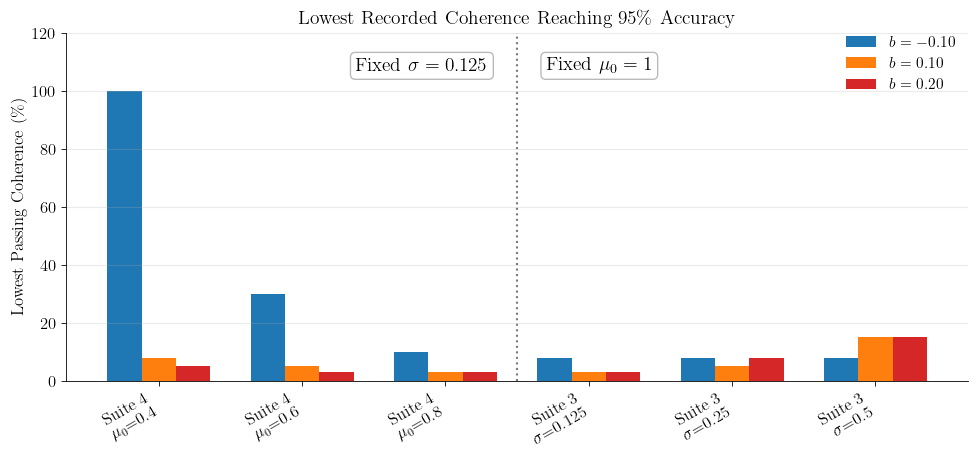

Saved: ..\..\figures\comparison\Pathway Bias - Lowest Passing Coherence for Accuracy.pdf
Saved: ..\..\figures\comparison\Pathway Bias - Lowest Passing Coherence for Accuracy.png


In [40]:
def plot_lowest_passing_coherence(
    comparison,
    title="Lowest Recorded Coherence Reaching 95\% Accuracy",
):
    plot_df = comparison.copy().reset_index(drop=True)
    plot_df["plot_pos"] = np.arange(len(plot_df))

    bias_cols = [r"$b = -0.10$", r"$b = 0.10$", r"$b = 0.20$"]
    parameter_labels = {
        "noise_std": r"$\sigma$",
        "strength": r"$\mu_0$",
    }
    labels = [
        f"{row.suite}\n{parameter_labels.get(row.level_parameter, row.level_parameter)}={row.level_value:g}"
        for row in plot_df.itertuples()
    ]

    x = plot_df["plot_pos"].to_numpy()
    width = 0.24
    offsets = (np.arange(len(bias_cols)) - (len(bias_cols) - 1) / 2) * width
    bar_colors = {r"$b = 0.20$": "tab:red"}

    fig, ax = plt.subplots(figsize=(10, 4.8))

    for col, offset in zip(bias_cols, offsets):
        ax.bar(x + offset, plot_df[col], width, label=col, color=bar_colors.get(col))

    suite_values = plot_df["suite"].to_numpy()
    suite_boundaries = np.where(suite_values[1:] != suite_values[:-1])[0] + 0.5
    for boundary in suite_boundaries:
        ax.axvline(
            boundary,
            color="0.35",
            linestyle=":",
            linewidth=1.5,
            alpha=0.8,
            zorder=0,
        )

    fixed_labels = {
        "noise_std": r"Fixed $\mu_0 = 1$",
        "strength": r"Fixed $\sigma = 0.125$",
    }
    box_style = dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="0.7",
        alpha=0.9,
    )
    separator_x = suite_boundaries[0] if len(suite_boundaries) else None
    box_gap = 0.2
    for suite, group in plot_df.groupby("suite", sort=False):
        group_center = group["plot_pos"].mean()
        level_parameter = group["level_parameter"].iloc[0]
        text_x = group_center
        text_ha = "center"
        if separator_x is not None:
            text_x = separator_x - box_gap if group_center < separator_x else separator_x + box_gap
            text_ha = "right" if group_center < separator_x else "left"
        ax.text(
            text_x,
            0.93,
            fixed_labels[level_parameter],
            transform=ax.get_xaxis_transform(),
            ha=text_ha,
            va="top",
            bbox=box_style,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("Lowest Passing Coherence (\%)")
    ax.set_title(title)
    ax.set_ylim(0, np.nanmax(plot_df[bias_cols].to_numpy()) * 1.2)
    ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1, 1.03))
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    return fig, ax


fig, ax = plot_lowest_passing_coherence(comparison)
plt.show()

save_plot(fig, 'Pathway Bias - Lowest Passing Coherence for Accuracy', folder='../../figures/comparison', formats=('pdf', 'png'))

# Lowest Passing Coherence - Mistakes

Due to the high amount of mistakes with increased levels of pathway bias, it could also be of interest to find the lowest passing coherence resulting in $5\%$ mistakes or less

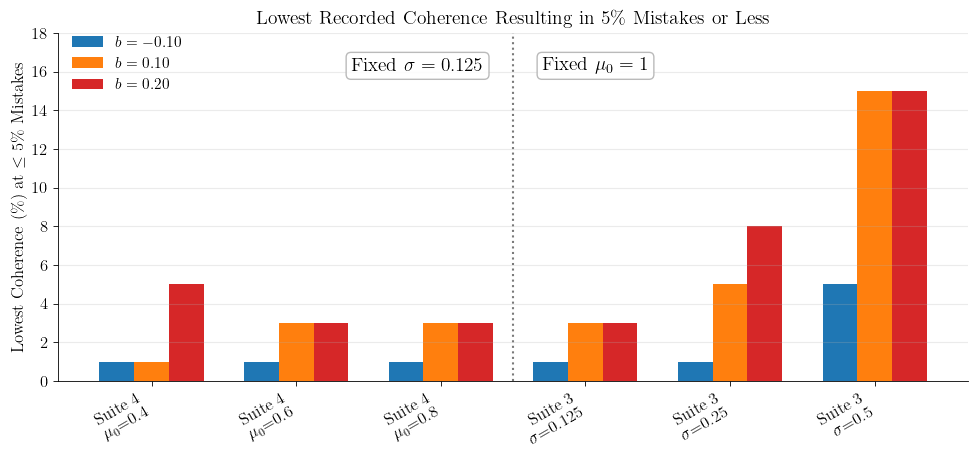

Saved: ..\..\figures\comparison\Pathway Bias - Lowest Passing Coherence for Mistakes.pdf
Saved: ..\..\figures\comparison\Pathway Bias - Lowest Passing Coherence for Mistakes.png


In [39]:
def get_lowest_mistake_thresholds(
    df,
    level_col,
    pathway_bias,
    suite_name,
    coherence_col="coherence",
    mistake_col="Wrong Decision (%)",
    mistake_cutoff=5,
):
    data = df.copy()
    data["coherence_pct"] = data[coherence_col] * 100

    mistake_table = (
        data.groupby([level_col, "coherence_pct"])[mistake_col]
        .mean()
        .reset_index(name="mistakes_pct")
        .sort_values([level_col, "coherence_pct"])
    )

    already_percent = "%" in mistake_col or "pct" in mistake_col.lower()
    if not already_percent and mistake_table["mistakes_pct"].dropna().max() <= 1:
        mistake_table["mistakes_pct"] *= 100

    rows = []
    for level_value, group in mistake_table.groupby(level_col):
        group = group.sort_values("coherence_pct")
        passing = group[group["mistakes_pct"] <= mistake_cutoff]

        rows.append(
            {
                "suite": suite_name,
                "level_parameter": level_col,
                "level_value": level_value,
                "pathway_bias": pathway_bias,
                "lowest_mistake_coherence_pct": (
                    np.nan if passing.empty else passing.iloc[0]["coherence_pct"]
                ),
            }
        )

    return pd.DataFrame(rows), mistake_table


def compare_lowest_mistake_coherence(
    suite3_summary_by_bias,
    suite4_summary_by_bias,
    suite3_level_col="noise_std",
    suite4_level_col="strength",
    mistake_cutoff=5,
):
    threshold_frames = []
    mistake_tables = []

    for pathway_bias, df in suite3_summary_by_bias.items():
        thresholds, mistake_table = get_lowest_mistake_thresholds(
            df=df,
            level_col=suite3_level_col,
            pathway_bias=pathway_bias,
            suite_name="Suite 3",
            mistake_cutoff=mistake_cutoff,
        )
        threshold_frames.append(thresholds)
        mistake_tables.append(mistake_table.assign(suite="Suite 3", pathway_bias=pathway_bias))

    for pathway_bias, df in suite4_summary_by_bias.items():
        thresholds, mistake_table = get_lowest_mistake_thresholds(
            df=df,
            level_col=suite4_level_col,
            pathway_bias=pathway_bias,
            suite_name="Suite 4",
            mistake_cutoff=mistake_cutoff,
        )
        threshold_frames.append(thresholds)
        mistake_tables.append(mistake_table.assign(suite="Suite 4", pathway_bias=pathway_bias))

    thresholds_long = pd.concat(threshold_frames, ignore_index=True)
    mistakes_by_coherence = pd.concat(mistake_tables, ignore_index=True)

    mistakes_comparison = (
        thresholds_long.pivot_table(
            index=["suite", "level_parameter", "level_value"],
            columns="pathway_bias",
            values="lowest_mistake_coherence_pct",
            aggfunc="first",
        )
        .reset_index()
        .rename_axis(columns=None)
    )

    bias_labels = {
        -0.10: r"$b = -0.10$",
        0.10: r"$b = 0.10$",
        0.20: r"$b = 0.20$",
    }
    mistakes_comparison = mistakes_comparison.rename(columns=bias_labels)

    suite_order = {"Suite 4": 0, "Suite 3": 1}
    mistakes_comparison["suite_order"] = mistakes_comparison["suite"].map(suite_order)
    mistakes_comparison = (
        mistakes_comparison.sort_values(["suite_order", "level_value"])
        .drop(columns="suite_order")
        .reset_index(drop=True)
    )

    return mistakes_comparison, thresholds_long, mistakes_by_coherence


def plot_lowest_mistake_coherence(
    mistakes_comparison,
    title="Lowest Recorded Coherence Resulting in 5\% Mistakes or Less",
):
    plot_df = mistakes_comparison.copy().reset_index(drop=True)
    plot_df["plot_pos"] = np.arange(len(plot_df))

    bias_cols = [r"$b = -0.10$", r"$b = 0.10$", r"$b = 0.20$"]
    parameter_labels = {
        "noise_std": r"$\sigma$",
        "strength": r"$\mu_0$",
    }
    labels = [
        f"{row.suite}\n{parameter_labels.get(row.level_parameter, row.level_parameter)}={row.level_value:g}"
        for row in plot_df.itertuples()
    ]

    x = plot_df["plot_pos"].to_numpy()
    width = 0.24
    offsets = (np.arange(len(bias_cols)) - (len(bias_cols) - 1) / 2) * width
    bar_colors = {r"$b = 0.20$": "tab:red"}

    fig, ax = plt.subplots(figsize=(10, 4.8))

    for col, offset in zip(bias_cols, offsets):
        ax.bar(x + offset, plot_df[col], width, label=col, color=bar_colors.get(col))

    suite_values = plot_df["suite"].to_numpy()
    suite_boundaries = np.where(suite_values[1:] != suite_values[:-1])[0] + 0.5
    for boundary in suite_boundaries:
        ax.axvline(
            boundary,
            color="0.35",
            linestyle=":",
            linewidth=1.5,
            alpha=0.8,
            zorder=0,
        )

    fixed_labels = {
        "noise_std": r"Fixed $\mu_0 = 1$",
        "strength": r"Fixed $\sigma = 0.125$",
    }
    box_style = dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="0.7",
        alpha=0.9,
    )
    separator_x = suite_boundaries[0] if len(suite_boundaries) else None
    box_gap = 0.2
    for suite, group in plot_df.groupby("suite", sort=False):
        group_center = group["plot_pos"].mean()
        level_parameter = group["level_parameter"].iloc[0]
        text_x = group_center
        text_ha = "center"
        if separator_x is not None:
            text_x = separator_x - box_gap if group_center < separator_x else separator_x + box_gap
            text_ha = "right" if group_center < separator_x else "left"
        ax.text(
            text_x,
            0.93,
            fixed_labels[level_parameter],
            transform=ax.get_xaxis_transform(),
            ha=text_ha,
            va="top",
            bbox=box_style,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("Lowest Coherence (\%) at $\leq 5\%$ Mistakes")
    ax.set_title(title)
    ax.set_ylim(0, np.nanmax(plot_df[bias_cols].to_numpy()) * 1.2)
    ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(0.15, 1.03))
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    return fig, ax


mistakes_comparison, mistake_thresholds_long, mistakes_by_coherence = compare_lowest_mistake_coherence(
    suite3_summary_by_bias=suite3_summary_by_bias,
    suite4_summary_by_bias=suite4_summary_by_bias,
    mistake_cutoff=5,
)

fig, ax = plot_lowest_mistake_coherence(mistakes_comparison)
plt.show()


save_plot(fig, 'Pathway Bias - Lowest Passing Coherence for Mistakes', folder='../../figures/comparison', formats=('pdf', 'png'))

In [38]:
mistakes_comparison

,suite,level_parameter,level_value,$b = -0.10$,$b = 0.10$,$b = 0.20$
0,Suite 4,strength,0.400,1.0,1.0,5.0
1,Suite 4,strength,0.600,1.0,3.0,3.0
2,Suite 4,strength,0.800,1.0,3.0,3.0
3,Suite 3,noise_std,0.125,1.0,3.0,3.0
4,Suite 3,noise_std,0.250,1.0,5.0,8.0
5,Suite 3,noise_std,0.500,5.0,15.0,15.0
